Load dataset

In [1]:
import os
import pandas as pd
import numpy as np

"""
    Read .csv files and store data into an array
    format: |LOS|NLOS|data...|
"""
rootdir = '../Dataset/UWB-LOS-NLOS-Data-Set/dataset/'
df = pd.DataFrame()
first = 1
for dirpath, _, filenames in os.walk(rootdir):
    for file in filenames:
        filename = os.path.join(dirpath, file)
        print(filename)
        # read data from file
        oneFileDF = pd.read_csv(filename)
        # append to array
        if first > 0:
            first = 0
            df = oneFileDF
        else:
            df = pd.concat([df, oneFileDF], ignore_index=True)

df

../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part1.csv
../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part2.csv
../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part3.csv
../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part4.csv
../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part5.csv
../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part6.csv
../Dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part7.csv


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,14948.0,96.0,9987.0,2379.0,276.0,...,180.0,156.0,322.0,378.0,115.0,296.0,452.0,138.0,123.0,0.0
41996,0.0,1.39,745.0,2235.0,15089.0,8796.0,76.0,12559.0,1810.0,281.0,...,43.0,433.0,517.0,518.0,287.0,169.0,437.0,59.0,296.0,0.0
41997,1.0,5.48,747.0,7115.0,6262.0,4584.0,72.0,1435.0,1092.0,1024.0,...,394.0,475.0,262.0,468.0,247.0,192.0,395.0,335.0,284.0,256.0
41998,1.0,3.40,745.0,6662.0,7683.0,5600.0,72.0,1491.0,1077.0,1024.0,...,397.0,170.0,231.0,231.0,202.0,253.0,128.0,311.0,290.0,0.0


Data Feature Extraction
- Extract most relevant features from dataset into dataframe

In [2]:
Features = ['NLOS','RANGE','FP_IDX','FP_AMP1','FP_AMP2','FP_AMP3','CIR_PWR','STDEV_NOISE','MAX_NOISE','RXPACC']
df = df.loc[:, Features]

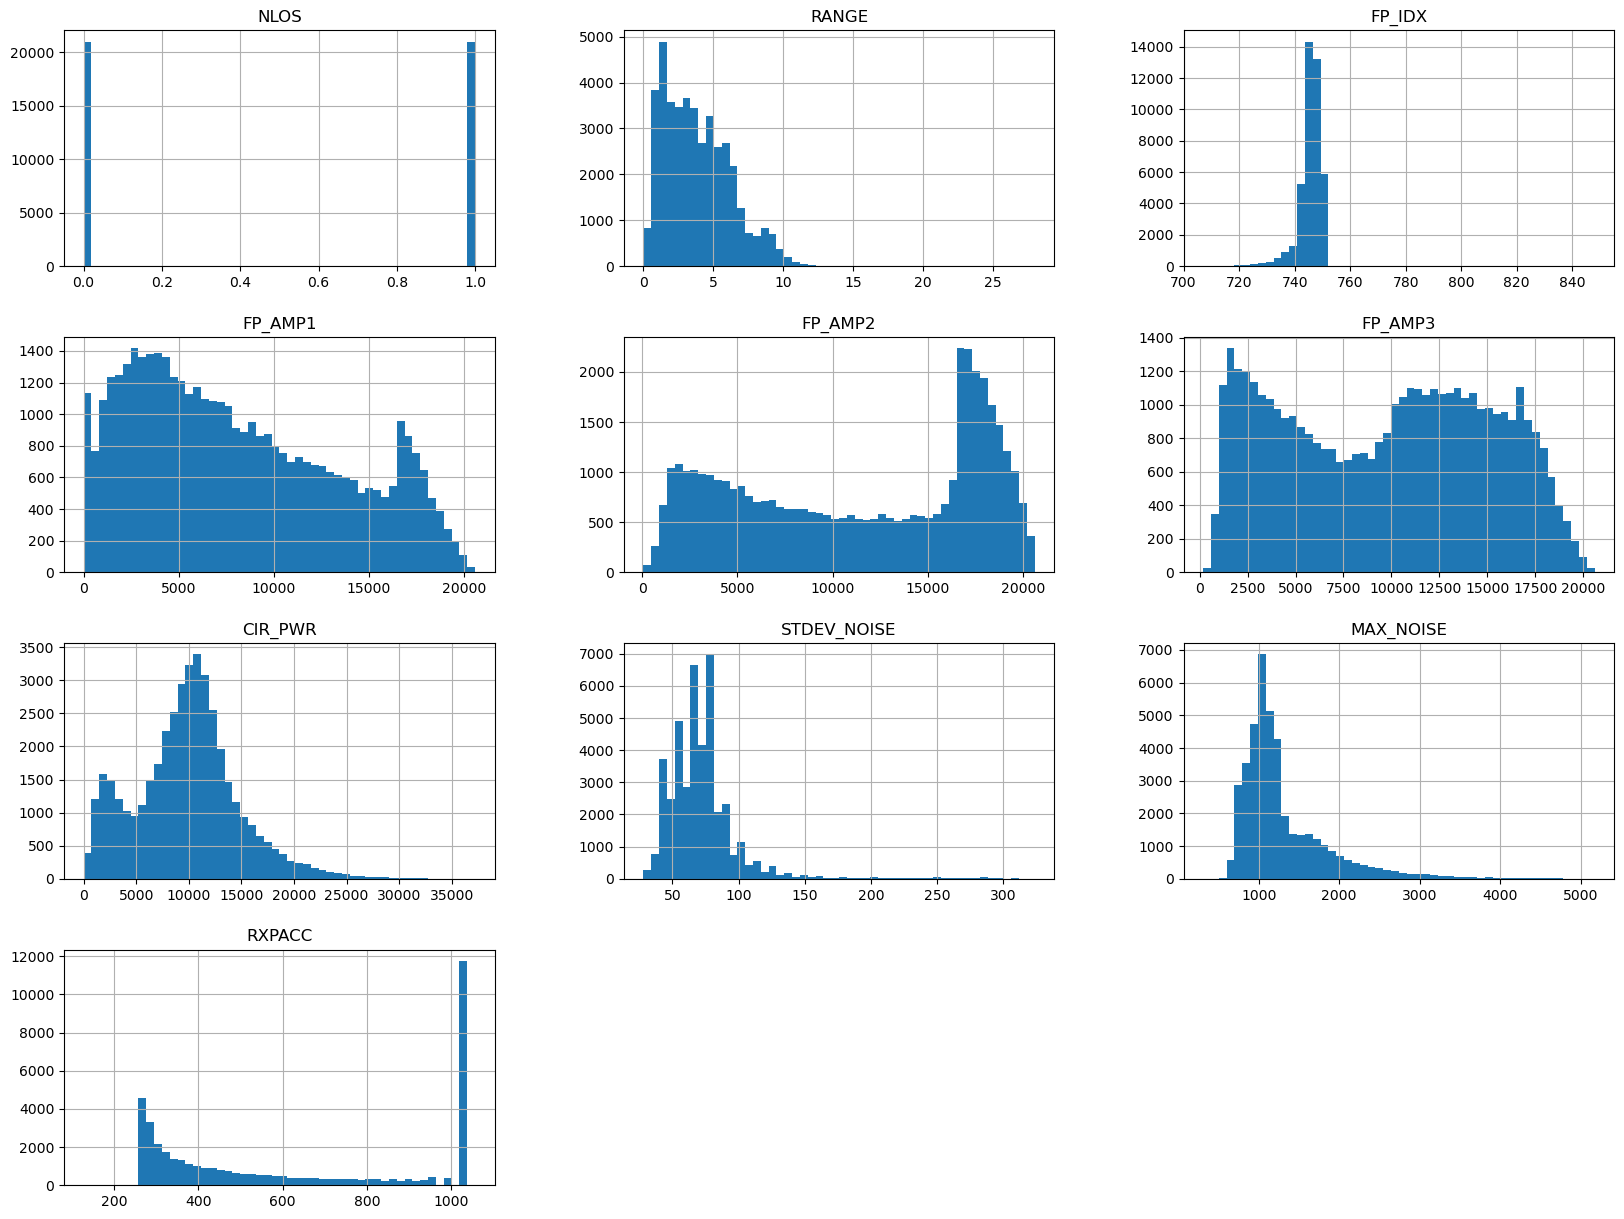

In [3]:
from matplotlib import pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

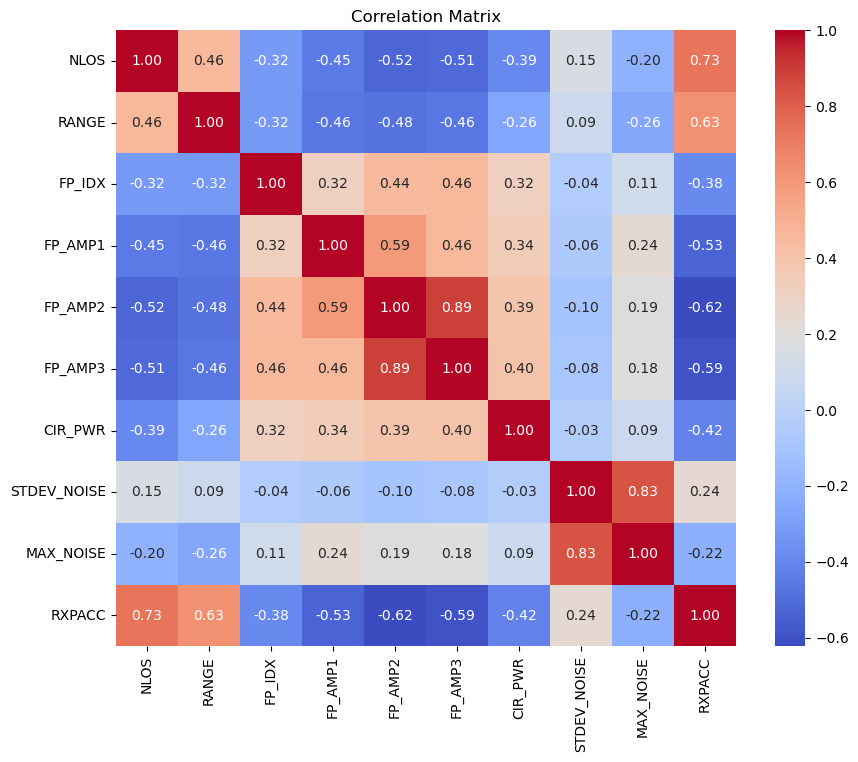

In [4]:
import seaborn as sns

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- Correlation between STDEV_NOISE and MAX_NOISE is high, and only one should be kept as a feature. So MAX_NOISE is chosen instead of STDEV_NOISE as a feature as it is more smoothly distributed as seen in the histograms. 

- Correlation between FP_AMP2 and FP_AMP3 is also high. So only one should be kept to eliminate feature redundancy.

In [5]:
df = df.drop(columns=['STDEV_NOISE'])
df = df.drop(columns=['FP_AMP3'])

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC
0,0.0,3.90,745.0,18712.0,10250.0,11855.0,967.0,611.0
1,0.0,0.66,749.0,11239.0,6313.0,18968.0,1133.0,447.0
2,1.0,7.86,746.0,4355.0,5240.0,14699.0,894.0,723.0
3,1.0,3.48,750.0,8502.0,8416.0,8748.0,1127.0,1024.0
4,0.0,1.19,746.0,17845.0,18095.0,11380.0,1744.0,276.0
...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,9987.0,2379.0,276.0
41996,0.0,1.39,745.0,2235.0,15089.0,12559.0,1810.0,281.0
41997,1.0,5.48,747.0,7115.0,6262.0,1435.0,1092.0,1024.0
41998,1.0,3.40,745.0,6662.0,7683.0,1491.0,1077.0,1024.0


Data Cleaning
- handle missing values or corrupt data

In [6]:
df.isna().sum()

NLOS         0
RANGE        0
FP_IDX       0
FP_AMP1      0
FP_AMP2      0
CIR_PWR      0
MAX_NOISE    0
RXPACC       0
dtype: int64

- Check for outliers using z-score filter


In [7]:
from scipy import stats

threshold = 3

for col in range(0, len(df.columns)):
    zscore = np.abs(stats.zscore(df.iloc[:, col]))
    outliers = np.where(zscore > threshold)
    print('Column:', df.columns[col], 'Outliers:', len(outliers[0]))

Column: NLOS Outliers: 0
Column: RANGE Outliers: 114
Column: FP_IDX Outliers: 735
Column: FP_AMP1 Outliers: 0
Column: FP_AMP2 Outliers: 0
Column: CIR_PWR Outliers: 296
Column: MAX_NOISE Outliers: 918
Column: RXPACC Outliers: 0


- Remove duplicate entries


In [8]:
dupes = df.duplicated()
print('Duplicates:', dupes.sum())

Duplicates: 0


- Ensure correct data types


In [9]:
print(df.dtypes)

NLOS         float64
RANGE        float64
FP_IDX       float64
FP_AMP1      float64
FP_AMP2      float64
CIR_PWR      float64
MAX_NOISE    float64
RXPACC       float64
dtype: object


Save preprocessed data to csv

In [11]:
df.to_csv('../Dataset/prepared/ClassifierPreparedDataset.csv', index=False)